### 🤖 Implement ReAct with LangGraph-What is ReAct?
ReAct (Reasoning + Acting) is a framework where an LLM:

- Reasons step-by-step (e.g. decomposes questions, makes decisions)

- Acts by calling tools like search, calculators, or retrievers

This makes it perfect for Agentic RAG:
✅ Think → Retrieve → Observe → Reflect → Final Answer

In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [2]:
from langchain_community.document_loaders import WebBaseLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# --------------------------
# 1. Create Retriever Tool
# --------------------------

# Load content from blog
docs = WebBaseLoader("https://lilianweng.github.io/posts/2023-06-23-agent/").load()

# Split text into document chunks
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)
chunks = splitter.split_documents(docs)

# Create embeddings
embedding = OpenAIEmbeddings()

# Create vectorstore
vectorstore = FAISS.from_documents(chunks, embedding)

# Create retriever
retriever = vectorstore.as_retriever()
retriever

USER_AGENT environment variable not set, consider setting it to identify your requests.
c:\Users\heman\Desktop\05 Ultimate RAG Bootcamp Using Langchain,LangGraph and Langsmith by Krish Naik\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x00000298E58B9010>, search_kwargs={})

In [3]:
retriever.invoke("what are autonomous agents")

[Document(id='f02d3c28-d979-46bd-a0ec-a42de402343f', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, essays and programs; it can be framed as a powerful general problem solver.\nAgent System Overview\nIn a LLM-powered autonomous agent system, LLM functions as the agent’s brain, complemented by several key components:\n\nPlanning\n\nSubgoal and decomposition: The agent breaks down large tasks into smaller, manageable subgoals, enabling efficient handling of complex tasks.\nReflection and refinement: The agent can do self-criticism and self-reflection over past actions, learn from mistakes and refine them for future steps, 

In [4]:

def retriever_tool_func(query: str) -> str:
    print("📚 Using RAGRetriever tool")
    docs = retriever.invoke(query)
    return "\n".join([doc.page_content for doc in docs])

In [5]:
query = "what are autonomous agents"

retriever_tool_func(query)

📚 Using RAGRetriever tool


'Or\n@article{weng2023agent,\n  title   = "LLM-powered Autonomous Agents",\n  author  = "Weng, Lilian",\n  journal = "lilianweng.github.io",\n  year    = "2023",\n  month   = "Jun",\n  url     = "https://lilianweng.github.io/posts/2023-06-23-agent/"\n}\nReferences#\n[1] Wei et al. “Chain of thought prompting elicits reasoning in large language models.” NeurIPS 2022\n[2] Yao et al. “Tree of Thoughts: Dliberate Problem Solving with Large Language Models.” arXiv preprint arXiv:2305.10601 (2023).\nCitation#\nCited as:\n\nWeng, Lilian. (Jun 2023). “LLM-powered Autonomous Agents”. Lil’Log. https://lilianweng.github.io/posts/2023-06-23-agent/.\nBoiko et al. (2023) also looked into LLM-empowered agents for scientific discovery, to handle autonomous design, planning, and performance of complex scientific experiments. This agent can use tools to browse the Internet, read documentation, execute code, call robotics experimentation APIs and leverage other LLMs.\nFor example, when requested to "deve

In [6]:
from langchain.agents import Tool

retriever_tool = Tool(
    name="RAGRetriever",
    description="Use this tool to fetch relevant knowledge base info",
    func=retriever_tool_func
)

print(retriever_tool)
print(retriever_tool.name)

name='RAGRetriever' description='Use this tool to fetch relevant knowledge base info' func=<function retriever_tool_func at 0x00000298C2A16A20>
RAGRetriever


In [7]:
from langchain.tools import WikipediaQueryRun
from langchain.utilities import WikipediaAPIWrapper

# Wikipedia tool
wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
wiki_tool

WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'c:\\Users\\heman\\Desktop\\05 Ultimate RAG Bootcamp Using Langchain,LangGraph and Langsmith by Krish Naik\\myenv\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))

In [8]:
# LLM Model
from langchain_openai import ChatOpenAI

llm = ChatOpenAI()
llm

ChatOpenAI(client=<openai.resources.chat.completions.completions.Completions object at 0x00000298E8A56270>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000298E8A57620>, root_client=<openai.OpenAI object at 0x00000298E5BF3610>, root_async_client=<openai.AsyncOpenAI object at 0x00000298E5BF3C50>, model_kwargs={}, openai_api_key=SecretStr('**********'))

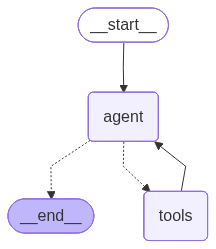

In [9]:
from langgraph.prebuilt import create_react_agent

# ----------------------------
# 2. Define the Agent Node
# ----------------------------

tools = [retriever_tool, wiki_tool]

## create the native Langgraph react agent
react_node = create_react_agent(llm, tools)
react_node

In [10]:
from typing import Annotated, TypedDict, Sequence
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# --------------------------
# 3. LangGraph Agent State
# --------------------------

class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

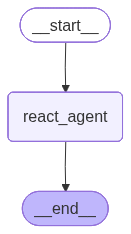

In [11]:
from langgraph.graph import StateGraph, START, END

# --------------------------
# 4. Build LangGraph Graph
# --------------------------

# Build the graph
graph = StateGraph(AgentState)

# Node
graph.add_node("react_agent", react_node)

# Edges
graph.add_edge(START, "react_agent")
graph.add_edge("react_agent", END)

# Compile
workflow = graph.compile()
workflow

In [12]:
from langchain_core.messages import HumanMessage

# --------------------------
# 5. Run the ReAct Agent
# --------------------------

if __name__ == "__main__":
    user_query = "What is an agent loop and how does Wikipedia describe autonomous agents?"
    state = {"messages": [HumanMessage(content=user_query)]}
    result = workflow.invoke(state)

    print("\n✅ Final Answer:\n", result["messages"][-1].content)


✅ Final Answer:
 An agent loop is not directly mentioned in the retrieved information. However, the Wikipedia page on "Intelligent agent" describes an intelligent agent as an entity that perceives its environment, takes actions autonomously to achieve goals, and may improve its performance through machine learning or by acquiring knowledge. Intelligent agents can range from simple to highly complex systems and operate based on an objective function that encapsulates their goals.

Autonomous agents, as described on Wikipedia, are artificial intelligence systems that can perform complex tasks independently. They are designed to carry out tasks without direct or continuous human guidance, showcasing capabilities like independent thinking, dynamic planning, and decision-making. These autonomous agents are seen as innovative solutions for various real-world applications.
